### Load and Modify Configuration File

In [1]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
x_domain : [-1, 1]
t_domain : [0, 1.0]
N_col : 1024
N_IC : 128
N_BC : 128
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 50000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 10
freq_print : 100
keys_print : ['loss_data', 'loss_IC', 'loss_BC', 'loss_AC']
freq_save : 1000
regularization : reg_derivative
reg_coeff : 1
reg_decay : linear
reg_epochs : 0.5


### Initialize Physics-Informed Neural Network

In [2]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

2025-04-01 13:18:35.756590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743506315.773891   12154 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743506315.778866   12154 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-01 13:18:35.794207: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning

Model: "PhysicsInformedNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,851 (30.67 KB)

 Trainable params: 7,851 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

*** DataLoader initialized ***
*** PINN build & initialized ***


### Train Physics-Informed Neural Network

In [3]:
training_logs = PINN.train()

Training started...
TensorShape([1024])
    0/50000 | loss_IC: 1.51e-01 | loss_BC: 3.36e-06 | loss_AC: 1.00e+00
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorShape([1024])
TensorSh

KeyboardInterrupt: 

# Plot Section

In [ ]:
from model.plots import learning_curves, allen_cahn_mesh, allen_cahn_xcut

### Learning Curves

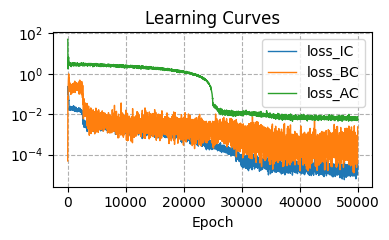

In [ ]:
learning_curves(training_logs)

### Allen-Cahn Dynamics (Mesh)

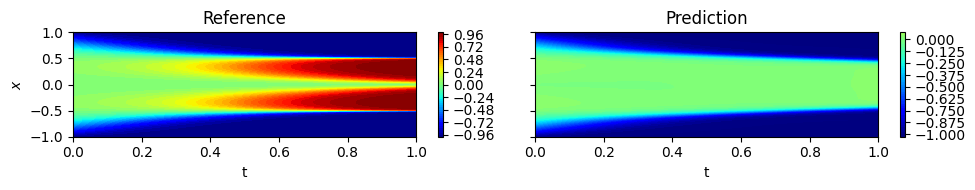

In [ ]:
allen_cahn_mesh(PINN)

### Allen-Cahn Dynamics (x-Cut)

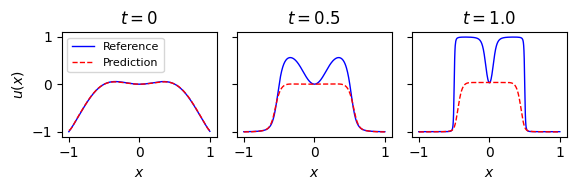

In [ ]:
allen_cahn_xcut(PINN, time_steps=[0, 0.5, 1.0])

(1024,)
0.5027189


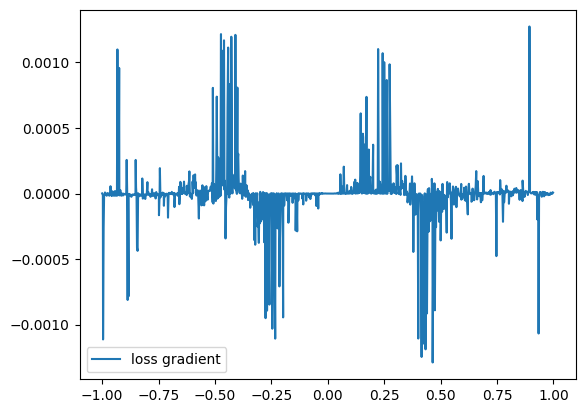

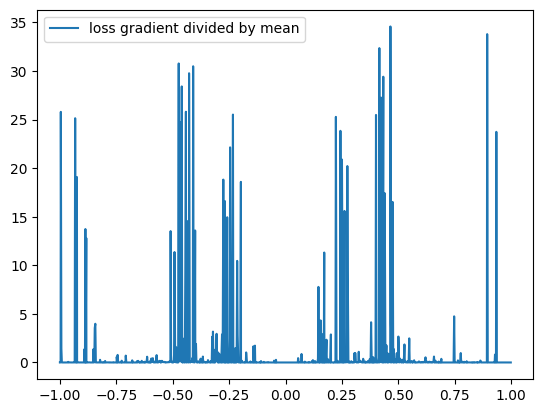

In [ ]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

# Reference data and PINN prediction
X_col = PINN.data.collocation() 

with tf.GradientTape() as tape:  
    tape.watch(X_col)      
    physics_loss = PINN.loss.allen_cahn(X_col, 0)
physics_loss_grad = tape.gradient(physics_loss, X_col)

ind = np.argsort(X_col[:, 0])

print(np.take(X_col, ind, axis=0)[:, 0].shape)
time_grad_physics_loss = np.take(physics_loss_grad, ind, axis=0)[:, 0]
normed_loss = (time_grad_physics_loss - np.min(time_grad_physics_loss)) / (np.max(time_grad_physics_loss) - np.min(time_grad_physics_loss))
print(np.mean(np.mean(normed_loss)))

# print(X_col[ind])
plt.figure()
plt.plot(np.take(X_col, ind, axis=0)[:, 0], np.take(physics_loss_grad, ind, axis=0)[:, 0], label="loss gradient")
plt.legend()
plt.show()

plt.figure()
plt.plot(np.take(X_col, ind, axis=0)[:, 0], np.take(physics_loss_grad, ind, axis=0)[:, 0]**2 / np.mean(np.take(physics_loss_grad, ind, axis=0)[:, 0]**2), label="loss gradient divided by mean")
plt.legend()
plt.show()

### Training animation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, axes = plt.subplots(1, 2, sharex=True, sharey=True,
                             figsize=(10, 2))

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, axes


def animate(i, *fargs):
    # get passed arguments
    axes = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    axes[0].clear()
    axes[1].clear()
    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))

    ############################
    # Prediciton plot
    ############################
    
    # get reference data and make prediction
    X_ref, u_ref = PINN.data.reference_mesh()
    u_pred = PINN(X_ref)

    # properties for tricontourf plot
    props = {'cmap': 'jet', 'levels': 50, 'vmin': -1, 'vmax': 1}
    # Reference
    axes[0].set_title('Reference')
    contf = axes[0].tricontourf(X_ref[:,1], X_ref[:,0], u_ref[:,0], **props)
    if i == 0:
        fig.colorbar(contf, ax=axes[0])

    # Prediction
    axes[1].set_title('Prediction')
    contf = axes[1].tricontourf(X_ref[:,1], X_ref[:,0], u_pred[:,0], **props)
    if i == 0:
        fig.colorbar(contf, ax=axes[1])
    
    ##############################
    ### Regularization coefficient
    ##############################
    epoch = flag
    # coeff = config["reg_coeff"] * (float(config["reg_decay"])**epoch)
    coeff = config["reg_coeff"] * (1 - epoch / config["reg_epochs"])
    if epoch > (config["reg_epochs"] * config["N_epochs"]):
        coeff = 0
    
    axes[1].plot([], [], c='black', lw=1, label=f'regularization coeff {coeff}')

    # Axis appearance
    axes[0].set_yticks([-1, -0.5, 0, 0.5, 1.0])
    axes[0].set_ylabel(r'$x$')
    for ax in axes:
        ax.set_xlabel(r't')

    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

<Figure size 640x480 with 0 Axes>